# 🥚 Egg Detection System using Deep Learning and YOLOv11n

Detect and count eggs in images, videos and live camera streams with a **YOLOv11n** (CNN-based) object detector fine-tuned on a Kaggle dataset.

**Run the cells from top to bottom.** Sections: setup → dataset → training → evaluation → prediction.

## 1. Install required packages

In [1]:
%pip install -q -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and configuration

In [13]:
import sys
from pathlib import Path

# make the project's src/ folder importable
SRC_DIR = Path.cwd().parent / "src" if Path.cwd().name == "notebooks" else Path.cwd() / "src"
sys.path.insert(0, str(SRC_DIR))

import cv2
import matplotlib.pyplot as plt

import utils, train, evaluate, predict

# ---------------- user settings ----------------
KAGGLE_DATASET = utils.KAGGLE_DATASET   # or write e.g. "owner/egg-detection"
EPOCHS = 200 #increase this for better results, but it will take longer to train
IMG_SIZE = 640
BATCH_SIZE = 4
LEARNING_RATE = 0.01
PATIENCE = 0                            # early stopping
CONFIDENCE_THRESHOLD = 0.25               # only detections >= this are displayed
EGG_CLASS_IDS = None                     # None = every annotated object is an egg
# -----------------------------------------------

DEVICE = utils.get_device()              # GPU if CUDA is available, otherwise CPU
print("Project root:", utils.PROJECT_ROOT)

[WARN] CUDA not available -> falling back to CPU (training will be slow).
Project root: E:\Deep Learning Projects\Egg-Detection-YOLOv11n


## 3. Kaggle API setup (secure)

1. On kaggle.com open **Settings → API → Create New Token** to download `kaggle.json`.
2. Move it to `~/.kaggle/kaggle.json` and run `chmod 600 ~/.kaggle/kaggle.json` (Windows: `C:\Users\<you>\.kaggle\`).
3. Or set the environment variables `KAGGLE_USERNAME` and `KAGGLE_KEY`.

> **Never** commit `kaggle.json` to GitHub or paste your key into a cell. The `.gitignore` already excludes it.

To discover a suitable dataset, run the optional search below and copy the `owner/slug` into `KAGGLE_DATASET` above.

In [3]:
# Optional: list Kaggle datasets that match a search term (requires credentials)
# utils.search_kaggle("egg detection")

## 4. Download the dataset programmatically

In [4]:
try:
    utils.download_kaggle_dataset(KAGGLE_DATASET)
except (FileNotFoundError, ValueError, ImportError) as err:
    print("[ERROR]", err)
    print("If you already have a YOLO-format egg dataset, copy it into", utils.RAW_DIR, "and continue.")

[INFO] Downloading 'uzairahmad1434/eggs-detection' to E:\Deep Learning Projects\Egg-Detection-YOLOv11n\dataset_raw ...
Dataset URL: https://www.kaggle.com/datasets/uzairahmad1434/eggs-detection


100%|██████████| 2.36M/2.36M [00:02<00:00, 1.04MB/s]


[INFO] Download complete.


## 5. Prepare the YOLO-format dataset and create `data.yaml`

In [14]:
counts = utils.prepare_dataset(utils.RAW_DIR, utils.DATASET_DIR, keep_class_ids=EGG_CLASS_IDS)
print(open(utils.DATA_YAML).read())

[INFO] Dataset prepared at E:\Deep Learning Projects\Egg-Detection-YOLOv11n\dataset  (skipped 0 images without labels)
       train:    42 images,   4128 eggs
       val  :    11 images,   1096 eggs
       test :     4 images,    393 eggs
path: E:/Deep Learning Projects/Egg-Detection-YOLOv11n/dataset
train: images/train
val: images/val
test: images/test
nc: 1
names:
  0: egg



## 6. Check the dataset structure

In [15]:
summary = utils.check_dataset_structure()

split   images  labels    eggs
train       42      42    4128
val         11      11    1096
test         4       4     393
classes: {0: 'egg'}


## 7. Sample images with their annotations

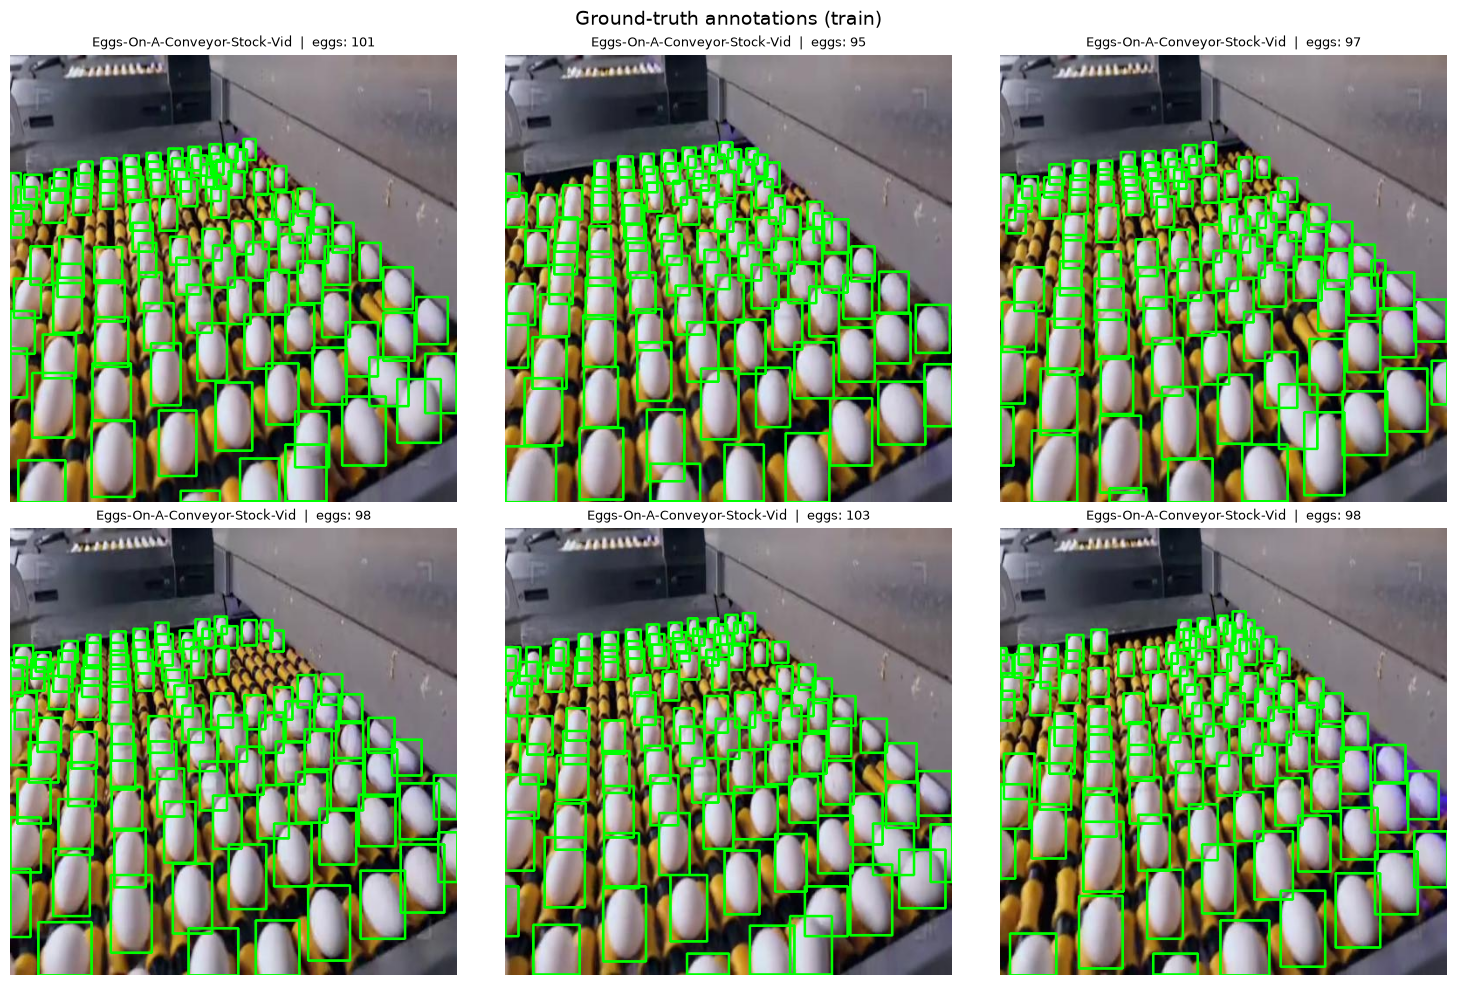

In [16]:
utils.show_samples("train", n=6)

## 8. Train YOLOv11n

The pretrained `yolo11n.pt` weights (COCO) are fine-tuned on the egg dataset – this is **transfer learning**.

In [17]:
best_weights, run_dir = train.train(
    epochs=EPOCHS, imgsz=IMG_SIZE, batch=BATCH_SIZE,
    lr0=LEARNING_RATE, patience=PATIENCE,
)
print("Best weights:", best_weights)
print("Run folder  :", run_dir)

split   images  labels    eggs
train       42      42    4128
val         11      11    1096
test         4       4     393
classes: {0: 'egg'}
[WARN] CUDA not available -> falling back to CPU (training will be slow).
New https://pypi.org/project/ultralytics/8.4.174 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.173  Python-3.12.7 torch-2.14.1+cpu CPU (Intel Xeon CPU E3-1505M v6 @ 3.00GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\Deep Learning Projects\Egg-Detection-YOLOv11n\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist

## 9. Training / validation loss curves

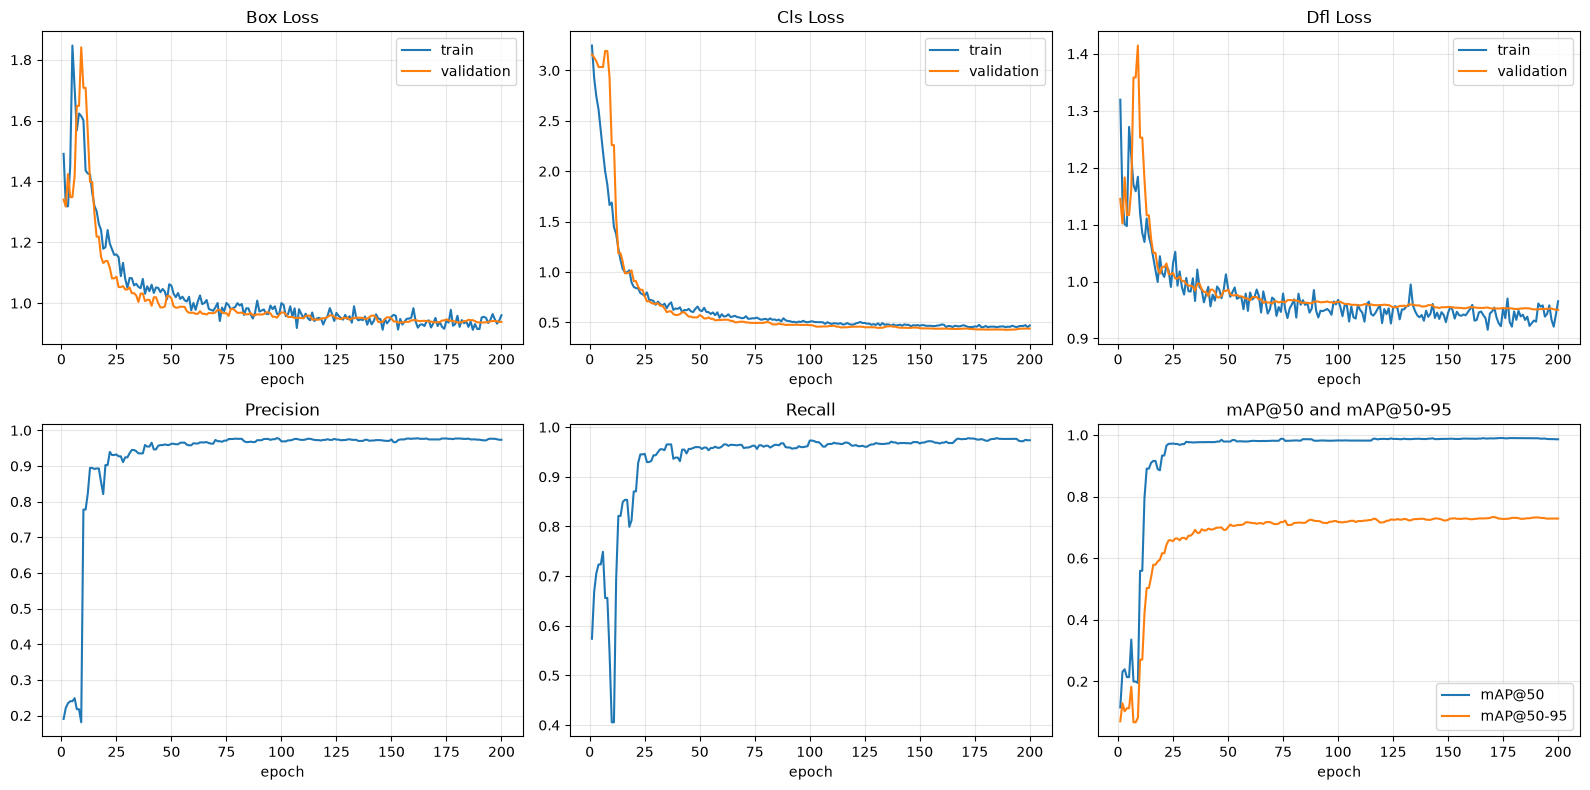

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
197,198,5438.25,0.93259,0.47261,0.92068,0.97488,0.97445,0.98667,0.72892,0.94017,0.43910,0.95127,0.00005,0.00005,0.00005
198,199,5464.18,0.94308,0.45324,0.94202,0.97354,0.97366,0.98620,0.72877,0.93836,0.43878,0.95052,0.00004,0.00004,0.00004
199,200,5489.66,0.96013,0.46931,0.96533,0.97354,0.97366,0.98620,0.72877,0.93836,0.43878,0.95052,0.00003,0.00003,0.00003


In [18]:
history = utils.plot_training_curves(utils.RUNS_DIR / utils.RUN_NAME / "results.csv",
                                     save_path=utils.OUTPUTS_DIR / "training_curves.png")
history.tail(3)

## 10. Evaluate on the test set

In [19]:
results = evaluate.evaluate(split="test", conf=CONFIDENCE_THRESHOLD, imgsz=IMG_SIZE)

split   images  labels    eggs
train       42      42    4128
val         11      11    1096
test         4       4     393
classes: {0: 'egg'}
[WARN] CUDA not available -> falling back to CPU (training will be slow).
Ultralytics 8.4.173  Python-3.12.7 torch-2.14.1+cpu CPU (Intel Xeon CPU E3-1505M v6 @ 3.00GHz)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 4.31.7 MB/s, size: 40.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning E:\Deep Learning Projects\Egg-Detection-YOLOv11n\dataset\labels\test... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 802.3it/s 0.0s
val: New cache created: E:\Deep Learning Projects\Egg-Detection-YOLOv11n\dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.9it

## 11. Evaluation visualisations

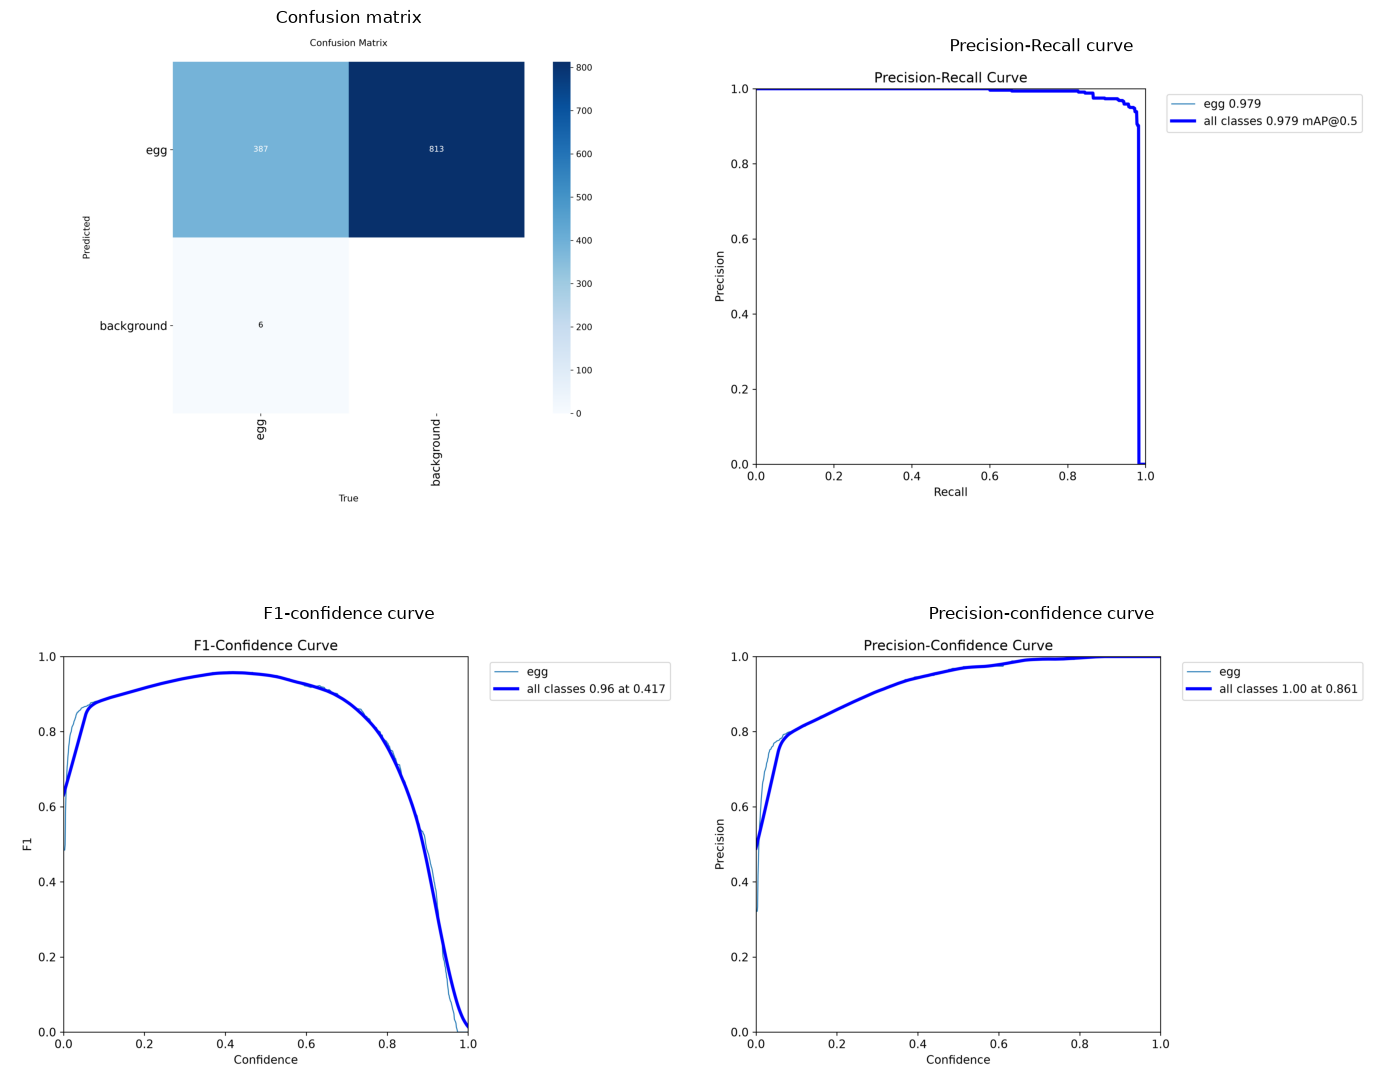

In [20]:
plots = Path(results["plots_dir"])
utils.show_images(
    [plots / "confusion_matrix.png", plots / "BoxPR_curve.png", plots / "BoxF1_curve.png", plots / "BoxP_curve.png"],
    ["Confusion matrix", "Precision-Recall curve", "F1-confidence curve", "Precision-confidence curve"],
)

## 12. Sample predictions on test images

[WARN] CUDA not available -> falling back to CPU (training will be slow).


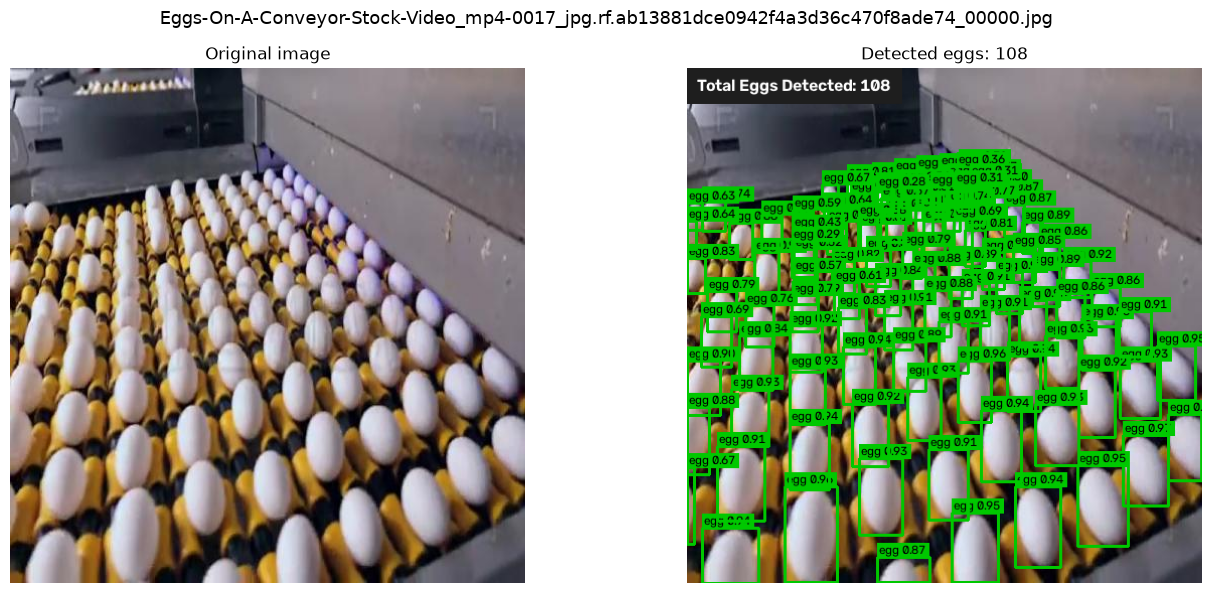

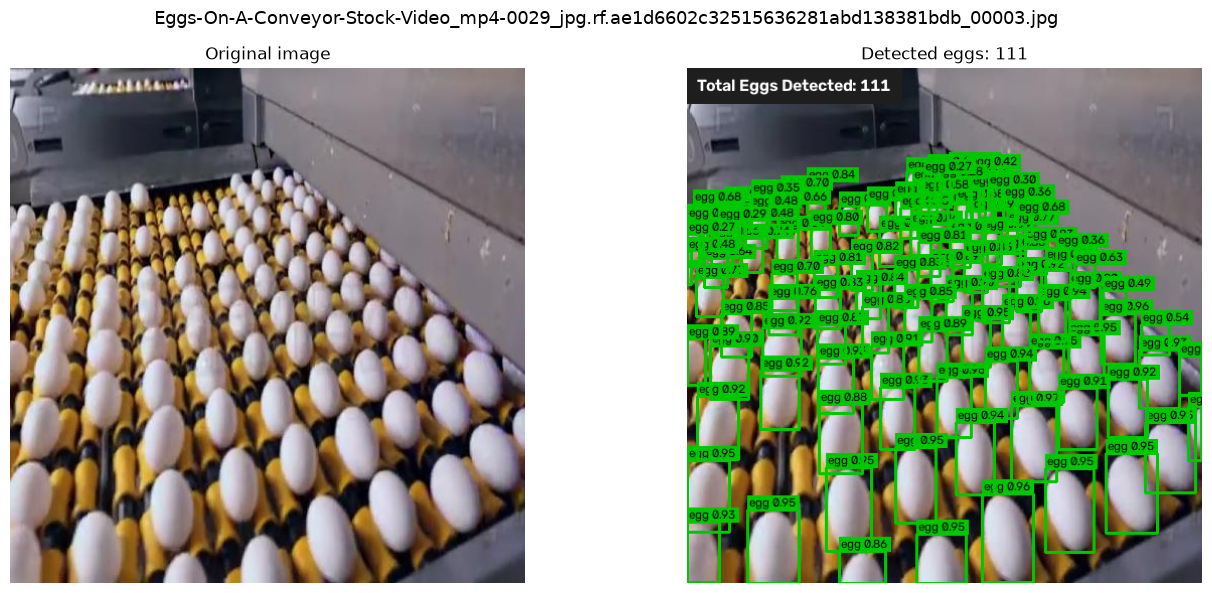

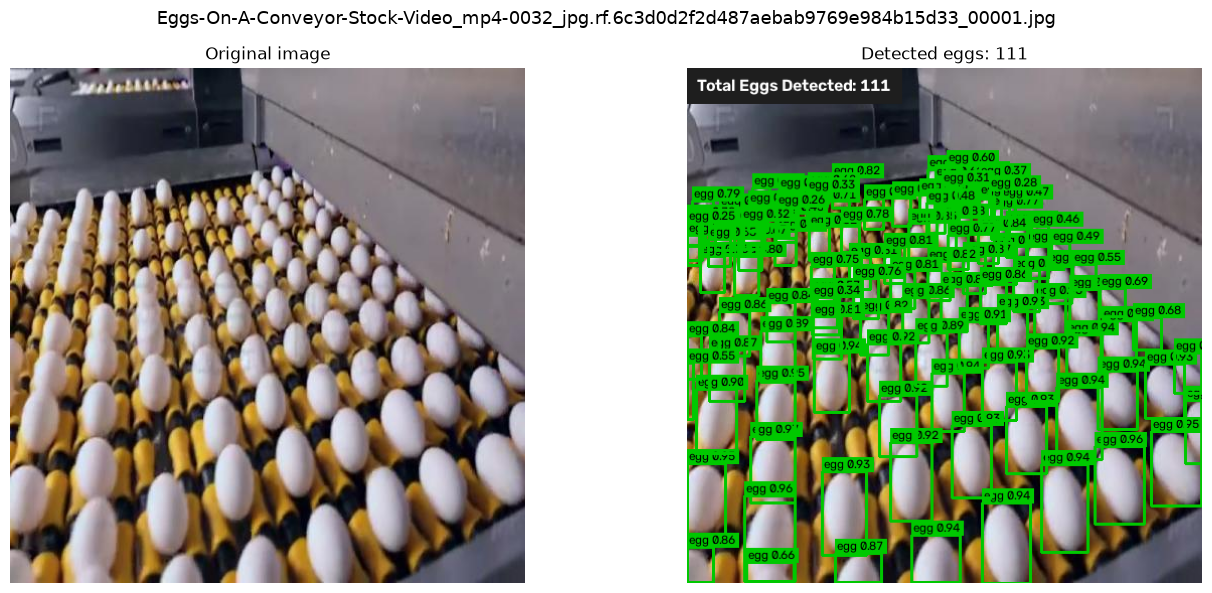

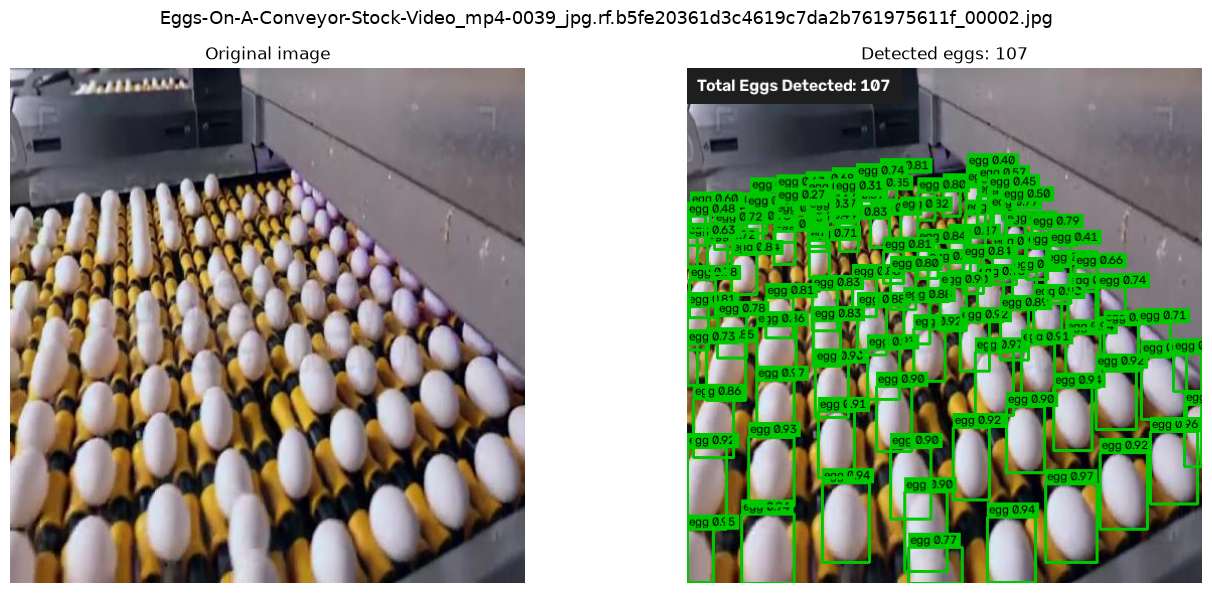

[INFO] Sample predictions saved to E:\Deep Learning Projects\Egg-Detection-YOLOv11n\outputs\sample_predictions_test


In [21]:
evaluate.save_sample_predictions(split="test", n=4, conf=CONFIDENCE_THRESHOLD, imgsz=IMG_SIZE, show=True)

## 13. Predict on a single image

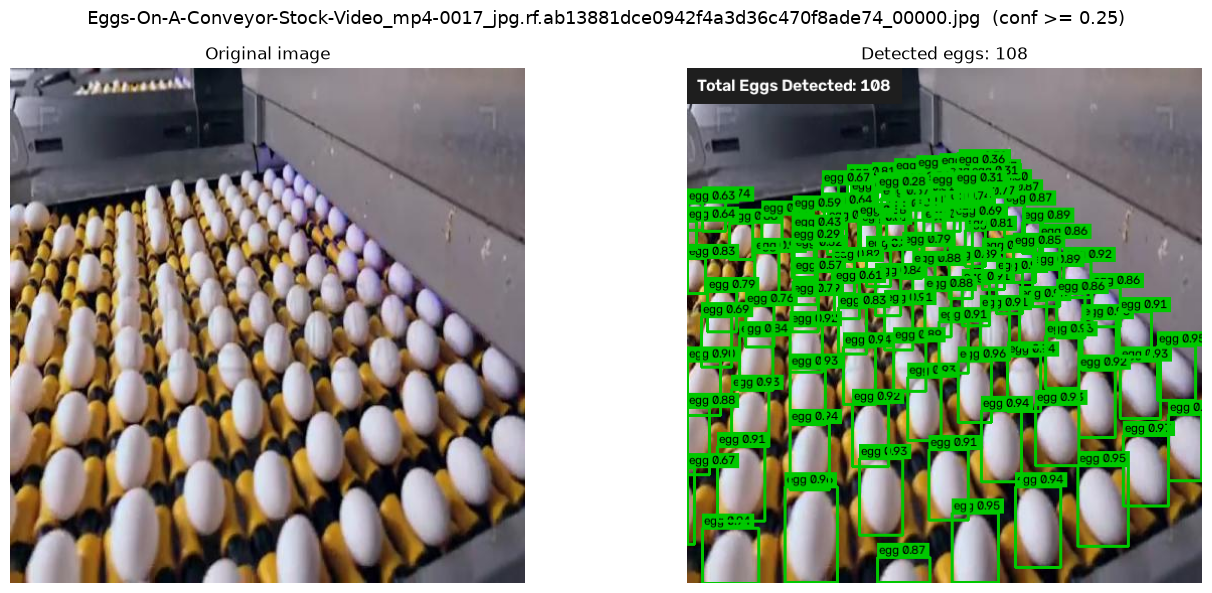

[RESULT] Eggs-On-A-Conveyor-Stock-Video_mp4-0017_jpg.rf.ab13881dce0942f4a3d36c470f8ade74_00000.jpg: Total Eggs Detected: 108


In [22]:
model = utils.load_model(utils.DEFAULT_WEIGHTS)
test_images = utils.list_images(utils.DATASET_DIR / "images" / "test")
SINGLE_IMAGE = test_images[0]            # or: Path("path/to/your_image.jpg")

n_eggs = predict.predict_image(model, SINGLE_IMAGE, conf=CONFIDENCE_THRESHOLD, imgsz=IMG_SIZE, device=DEVICE)

## 14. Predict on multiple images

In [23]:
counts = predict.predict_images(model, test_images[:5], conf=CONFIDENCE_THRESHOLD, imgsz=IMG_SIZE, device=DEVICE)
counts

[RESULT] Eggs-On-A-Conveyor-Stock-Video_mp4-0017_jpg.rf.ab13881dce0942f4a3d36c470f8ade74_00000.jpg: Total Eggs Detected: 108
[RESULT] Eggs-On-A-Conveyor-Stock-Video_mp4-0029_jpg.rf.ae1d6602c32515636281abd138381bdb_00003.jpg: Total Eggs Detected: 111
[RESULT] Eggs-On-A-Conveyor-Stock-Video_mp4-0032_jpg.rf.6c3d0d2f2d487aebab9769e984b15d33_00001.jpg: Total Eggs Detected: 111
[RESULT] Eggs-On-A-Conveyor-Stock-Video_mp4-0039_jpg.rf.b5fe20361d3c4619c7da2b761975611f_00002.jpg: Total Eggs Detected: 107
[SUMMARY] 4 images processed, 437 eggs detected in total.


{'Eggs-On-A-Conveyor-Stock-Video_mp4-0017_jpg.rf.ab13881dce0942f4a3d36c470f8ade74_00000.jpg': 108,
 'Eggs-On-A-Conveyor-Stock-Video_mp4-0029_jpg.rf.ae1d6602c32515636281abd138381bdb_00003.jpg': 111,
 'Eggs-On-A-Conveyor-Stock-Video_mp4-0032_jpg.rf.6c3d0d2f2d487aebab9769e984b15d33_00001.jpg': 111,
 'Eggs-On-A-Conveyor-Stock-Video_mp4-0039_jpg.rf.b5fe20361d3c4619c7da2b761975611f_00002.jpg': 107}

## 15. Predict on a video

In [24]:
VIDEO_PATH = Path("../sample_video.mp4")  # put your own video here

if VIDEO_PATH.exists():
    out_video, frame_counts = predict.predict_video(model, VIDEO_PATH, conf=CONFIDENCE_THRESHOLD, imgsz=IMG_SIZE, device=DEVICE)
    plt.plot(frame_counts); plt.xlabel("frame"); plt.ylabel("eggs detected"); plt.title("Eggs per frame"); plt.show()
else:
    print(f"[INFO] No video at {VIDEO_PATH.resolve()} - set VIDEO_PATH to try this cell.")

[INFO] No video at E:\Deep Learning Projects\Egg-Detection-YOLOv11n\sample_video.mp4 - set VIDEO_PATH to try this cell.


## 16. Webcam / live camera

Opens an OpenCV window (press **q** to quit, **s** for a snapshot). It needs a local machine with a camera and display, so it is switched off by default.

In [25]:
RUN_WEBCAM = False

if RUN_WEBCAM:
    try:
        predict.predict_webcam(model, camera=0, conf=CONFIDENCE_THRESHOLD, imgsz=IMG_SIZE, device=DEVICE)
    except RuntimeError as err:
        print("[ERROR]", err)

## 17. Summary

| Item | Value |
|---|---|
| Model | YOLOv11n (fine-tuned from COCO-pretrained weights) |
| Task | Single-class object detection (`0: egg`) |
| Outputs | `models/egg_yolo11n_best.pt`, `outputs/`, `runs/` |

Scroll back to the evaluation section for Precision, Recall, mAP@50 and mAP@50-95 on your dataset.